# 神經網路

你在烘咖啡。每一爐有兩個數：溫度（°C）和時間（分鐘）。結果只有烘得好或烘不好。好烘大致落在 175–260°C、12–15 分鐘這一塊，而且時間不能比溫度允許的上限更長。

這一份用一個小神經網路學這塊區域。網路有兩層 sigmoid：輸入 2 個特徵，第一層 3 個單元，第二層 1 個單元。程式已經寫好。請 agent 改的格子，標題會寫「實驗」。下面這種格子只有你能寫，agent 不要填、不要改寫：

### 你的觀察


## 給 agent

- 可以改標題含「實驗」的程式格，也可以依學生當下的問題加新的程式格。
- 不要改標題是「你的觀察」的格子，也不要替學生寫結論。
- 不要改學習率、epoch、複製份數，也不要拿掉後面存好的權重，除非學生明確說要比較這一次訓練的結果。
- 學生若只說「幫我做完」，先問他想把门檻調高還是調低，再改程式。


## 資料是造出來的

沒有資料檔。下一格用固定種子造 200 筆，所以每次圖一樣。紅色叉是好烘，藍色圈是不好。紫線標出造資料時用的那塊好烘區域，不是模型畫的。


形狀 (200, 2) (200, 1)
溫度最小/最大 151.3 285.0
時間最小/最大 11.5 15.5
好烘筆數 43


d:\Work\Python\Machine-Learning-Lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 22909 (\N{CJK UNIFIED IDEOGRAPH-597D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Work\Python\Machine-Learning-Lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 28888 (\N{CJK UNIFIED IDEOGRAPH-70D8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Work\Python\Machine-Learning-Lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 19981 (\N{CJK UNIFIED IDEOGRAPH-4E0D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


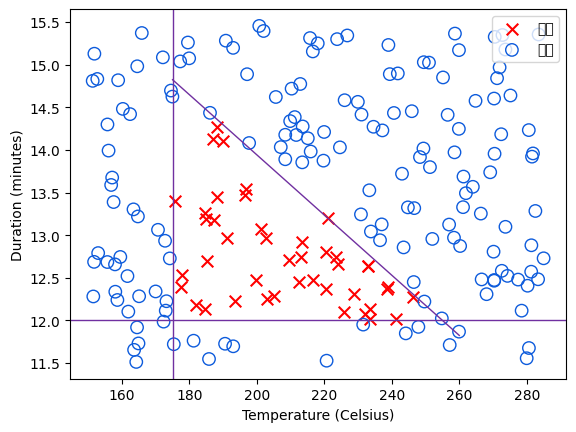

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei", "Noto Sans TC", "Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

tf.random.set_seed(1234)
tf.get_logger().setLevel("ERROR")

def load_coffee_data():
    rng = np.random.default_rng(2)
    X = rng.random(400).reshape(-1, 2)
    X[:, 1] = X[:, 1] * 4 + 11.5
    X[:, 0] = X[:, 0] * (285 - 150) + 150
    Y = np.zeros(len(X))
    for i, (temperature, duration) in enumerate(X):
        limit = -3 / (260 - 175) * temperature + 21
        good = (
            175 < temperature < 260
            and 12 < duration < 15
            and duration <= limit
        )
        Y[i] = 1 if good else 0
    return X, Y.reshape(-1, 1)

def draw_good_region(ax):
    temperature = np.linspace(175, 260, 50)
    ax.plot(temperature, (-3 / 85) * temperature + 21, color="#7030A0", linewidth=1)
    ax.axhline(12, color="#7030A0", linewidth=1)
    ax.axvline(175, color="#7030A0", linewidth=1)

X, Y = load_coffee_data()
print("形狀", X.shape, Y.shape)
print("溫度最小/最大", round(float(X[:, 0].min()), 1), round(float(X[:, 0].max()), 1))
print("時間最小/最大", round(float(X[:, 1].min()), 1), round(float(X[:, 1].max()), 1))
print("好烘筆數", int(Y.sum()))

good = Y.reshape(-1) == 1
fig, ax = plt.subplots()
ax.scatter(X[good, 0], X[good, 1], marker="x", c="red", s=70, label="好烘")
ax.scatter(X[~good, 0], X[~good, 1], marker="o", facecolors="none", edgecolors="#0D5BDC", s=80, label="不好")
draw_good_region(ax)
ax.set_xlabel("Temperature (Celsius)")
ax.set_ylabel("Duration (minutes)")
ax.legend(loc="upper right")
plt.show()


### 你的觀察

看完散點再寫。agent 不要填。

好烘是不是集中在某一塊？溫度太低或時間太長時，看起來怎樣？


## 先把尺度拉齊，再訓練

溫度是一百多度，時間是十幾分鐘。尺度差這麼多時，同一步長會被溫度拉著走。這裡用 Keras 的 `Normalization`，用這 200 筆自己的平均和標準差把兩個特徵拉到差不多的尺度。之後預測新的一爐，也要用同一組平均和標準差。

訓練把這 200 筆複製 1000 份，讓每個 epoch 多看幾次同樣的例子。損失是二元交叉熵，優化器是 Adam，學習率 `0.01`，跑 10 個 epoch。這些數字寫死，不在這一格改。


In [ ]:
norm_l = tf.keras.layers.Normalization(axis=-1)
norm_l.adapt(X)
Xn = norm_l(X)
print(
    "正規化後 溫度 最小/最大",
    round(float(np.min(Xn[:, 0])), 2),
    round(float(np.max(Xn[:, 0])), 2),
)
print(
    "正規化後 時間 最小/最大",
    round(float(np.min(Xn[:, 1])), 2),
    round(float(np.max(Xn[:, 1])), 2),
)

Xt = np.tile(Xn, (1000, 1))
Yt = np.tile(Y, (1000, 1))
print("複製後的形狀", Xt.shape, Yt.shape)

model = Sequential(
    [
        tf.keras.Input(shape=(2,)),
        Dense(3, activation="sigmoid", name="layer1"),
        Dense(1, activation="sigmoid", name="layer2"),
    ]
)
model.compile(
    loss=tf.keras.losses.BinaryCrossentropy(),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
)
history = model.fit(Xt, Yt, epochs=10, verbose=0)
print("每個 epoch 的損失", [round(float(v), 3) for v in history.history["loss"]])

plt.plot(history.history["loss"], marker="o")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Loss should fall")
plt.show()


## 單元圖用存好的權重

上面那次訓練的損失會下降，但三個隱藏單元沒有固定座位。這一次 1 號學到「太冷」，下一次可能改學「時間太短」。

下面換成講義裡存好的權重。這組權重是在正規化之後的特徵上用的，所以還是先經過 `norm_l`。換成這組之後，三張圖每次打開都一樣：一個單元在溫度太低時輸出比較大，一個在時間太短（也含太久的一塊）時比較大，第三個補上剩下的不好區域。


In [ ]:
W1 = np.array(
    [
        [-8.94, 0.29, 12.89],
        [-0.17, -7.34, 10.79],
    ]
)
b1 = np.array([-9.87, -9.28, 1.01])
W2 = np.array([[-31.38], [-27.86], [-32.79]])
b2 = np.array([15.54])
model.get_layer("layer1").set_weights([W1, b1])
model.get_layer("layer2").set_weights([W2, b2])

def unit_grid(unit):
    temperature = np.linspace(150, 285, 40)
    duration = np.linspace(11.5, 15.5, 40)
    tt, dd = np.meshgrid(temperature, duration)
    raw = np.column_stack([tt.ravel(), dd.ravel()])
    xn = np.asarray(norm_l(raw))
    z = xn @ W1[:, unit] + b1[unit]
    prob = 1 / (1 + np.exp(-np.clip(z, -500, 500)))
    return tt, dd, prob.reshape(tt.shape)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for unit, ax in enumerate(axes):
    tt, dd, prob = unit_grid(unit)
    shade = ax.pcolormesh(tt, dd, prob, cmap="Blues", vmin=0, vmax=1, shading="nearest")
    ax.scatter(X[good, 0], X[good, 1], marker="x", c="red", s=30)
    ax.scatter(X[~good, 0], X[~good, 1], marker="o", facecolors="none", edgecolors="#0D5BDC", s=30)
    draw_good_region(ax)
    ax.set_title(f"layer 1, unit {unit}")
    ax.set_xlabel("Temperature (Celsius)")
fig.colorbar(shade, ax=axes.ravel().tolist())
axes[0].set_ylabel("Duration (minutes)")
plt.show()


下一格只改門檻。模型輸出的是「好烘」的機會。門檻放低，更多爐被判成好烘；放高則相反。兩筆試烘是 `200°C、13.9 分鐘`（落在好烘區裡）和 `200°C、17 分鐘`（時間太長）。


In [ ]:
# 實驗：改 threshold，看判成好烘的範圍變大還變小
threshold = 0.5

X_test = np.array(
    [
        [200, 13.9],
        [200, 17],
    ]
)
test_prob = model.predict(norm_l(X_test), verbose=0).reshape(-1)
test_decision = (test_prob >= threshold).astype(int)
for row, prob, decision in zip(X_test, test_prob, test_decision):
    label = "好烘" if decision == 1 else "不好"
    print(f"{row[0]:.0f}°C、{row[1]} 分鐘 → 機會 {prob:.3f} → {label}")

temperature = np.linspace(150, 285, 50)
duration = np.linspace(11.5, 15.5, 50)
tt, dd = np.meshgrid(temperature, duration)
raw = np.column_stack([tt.ravel(), dd.ravel()])
grid_prob = model.predict(norm_l(raw), verbose=0).reshape(tt.shape)

fig, ax = plt.subplots()
ax.contourf(tt, dd, grid_prob >= threshold, levels=[-0.1, 0.5, 1.1], colors=["#d6e6ff", "#ffd6d6"], alpha=0.8)
ax.scatter(X[good, 0], X[good, 1], marker="x", c="red", s=40, label="實際好烘")
ax.scatter(X[~good, 0], X[~good, 1], marker="o", facecolors="none", edgecolors="#0D5BDC", s=40, label="實際不好")
draw_good_region(ax)
ax.set_title(f"threshold {threshold}")
ax.set_xlabel("Temperature (Celsius)")
ax.set_ylabel("Duration (minutes)")
ax.legend(loc="upper right")
plt.show()


### 你的觀察

只寫你自己的話。agent 不要填。

1. 三個單元裡，你看得出哪一個在管溫度太低、哪一個在管時間嗎：
2. 門檻從 0.5 調高之後，`17 分鐘` 那一筆還是不好。`13.9 分鐘` 那一筆呢：
3. 圖上判成好烘的顏色區域變大還變小。它有沒有蓋過紫線外面：
4. 若你是烘焙師，你會把門檻放高還是放低：


## 這本沒有收進來的

不從 GitHub 下載 utils，也不貼講義圖。第二層那個 3D 單元圖不在這本。單元圖用的是存好的權重，不是上面那一次 `fit` 當下的權重。
